In [17]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [18]:
BASE = '../examples/comparisons/combined_boundary_DIIID'

def load_run(run_dir):
    """Load results.json if present, else checkpoint.json. Returns flat dict."""
    results_path = os.path.join(run_dir, 'results.json')
    ckpt_path = os.path.join(run_dir, 'checkpoint.json')
    if os.path.exists(results_path):
        with open(results_path) as f:
            raw = json.load(f)
        s = raw['optimization_settings']
        method_name = list(raw['methods'].keys())[0]
        d = raw['methods'][method_name]
        d['optimization_settings'] = s
        d['method'] = method_name
        d['source'] = 'results'
        return d
    elif os.path.exists(ckpt_path):
        with open(ckpt_path) as f:
            d = json.load(f)
        d['source'] = 'checkpoint'
        return d
    return None

def discover_runs(base):
    runs = []
    for sweep in sorted(os.listdir(base)):
        sweep_dir = os.path.join(base, sweep)
        if not os.path.isdir(sweep_dir):
            continue
        for config in sorted(os.listdir(sweep_dir)):
            config_dir = os.path.join(sweep_dir, config)
            if not os.path.isdir(config_dir):
                continue
            for run in sorted(os.listdir(config_dir)):
                run_dir = os.path.join(config_dir, run)
                if not os.path.isdir(run_dir):
                    continue
                d = load_run(run_dir)
                if d is None:
                    continue
                s = d.get('optimization_settings', {})
                runs.append({
                    'sweep': sweep,
                    'config': config,
                    'run': run,
                    'run_dir': run_dir,
                    'source': d['source'],
                    'method': d.get('method', '?'),
                    'weight_fb': s.get('weight_fb', float('nan')),
                    'alpha': s.get('alpha', float('nan')),
                    'num_coils': s.get('num_coils', '?'),
                    'n_evals': d.get('n_evals', float('nan')),
                    'best_cost': d.get('best_cost', float('nan')),
                    'best_flux_err': d.get('best_flux_err', float('nan')),
                    'best_fb_cost': d.get('best_fb_cost', float('nan')),
                    'fb_failures': d.get('fb_failures', float('nan')),
                    'elapsed': d.get('elapsed', d.get('time', float('nan'))),
                    'stopping': d.get('stopping', '?'),
                    'data': d,
                })
    return runs

runs = discover_runs(BASE)
print(f"{len(runs)} runs found")
for r in runs:
    print(f"  {r['sweep']}/{r['config']}/{r['run']}  [{r['source']}]  method={r['method']}  weight_fb={r['weight_fb']:.0e}  best={r['best_cost']:.4e}  evals={r['n_evals']}  stop={r['stopping']}")

8 runs found
  convergence_w5/alpha:0.75,weight:1e-01,lambda:1e-06,coils:3/run_01  [checkpoint]  method=L-BFGS  weight_fb=1e-01  best=2.7644e-01  evals=1281  stop=in_progress
  convergence_w5/alpha:0.75,weight:1e-02,lambda:1e-06,coils:3/run_01  [checkpoint]  method=L-BFGS  weight_fb=1e-02  best=3.6636e-01  evals=1236  stop=in_progress
  convergence_w5/alpha:0.75,weight:1e-03,lambda:1e-06,coils:3/run_01  [checkpoint]  method=L-BFGS  weight_fb=1e-03  best=3.7611e-01  evals=1275  stop=in_progress
  convergence_w5/alpha:0.75,weight:1e-04,lambda:1e-06,coils:3/run_01  [checkpoint]  method=L-BFGS  weight_fb=1e-04  best=1.2086e-01  evals=1233  stop=in_progress
  convergence_w5_bayesian/alpha:0.75,weight:1e-01,lambda:1e-06,coils:3/run_01  [results]  method=Bayesian  weight_fb=1e-01  best=9.4196e-01  evals=574  stop=all refinements completed
  convergence_w5_bayesian/alpha:0.75,weight:1e-02,lambda:1e-06,coils:3/run_01  [checkpoint]  method=Bayesian  weight_fb=1e-02  best=6.4825e-01  evals=699  s

In [19]:
rows = []
for r in runs:
    d = r['data']
    alpha = d.get('optimization_settings', {}).get('alpha', 0.75)
    rows.append({
        'sweep': r['sweep'],
        'method': r['method'],
        'weight_fb': r['weight_fb'],
        'num_coils': r['num_coils'],
        'source': r['source'],
        'alpha': alpha,
        'best_cost_stored': r['best_cost'],
        'best_flux_err': r['best_flux_err'],
        'best_fb_cost': r['best_fb_cost'],
        'init_fixed': d.get('initial_fixed_cost') or float('nan'),
        'init_fb': d.get('initial_fb_cost') or float('nan'),
        'fb_failures': r['fb_failures'],
        'n_evals': r['n_evals'],
        'elapsed_h': r['elapsed'] / 3600,
        'stopping': r['stopping'],
    })

df = pd.DataFrame(rows)

shared_norm_fixed = df['init_fixed'].max()
shared_norm_fb = df['init_fb'].max()
print(f"shared_norm_fixed={shared_norm_fixed:.4e}  shared_norm_fb={shared_norm_fb:.4e}")

df['best_cost_shared'] = (
    (1 - df['alpha']) * df['best_flux_err'] / shared_norm_fixed +
    df['alpha'] * df['best_fb_cost'] / shared_norm_fb
)

df = df.sort_values(['sweep', 'weight_fb'])
pd.set_option('display.float_format', '{:.4e}'.format)
df

shared_norm_fixed=2.0760e-01  shared_norm_fb=9.5215e+00


,sweep,method,weight_fb,num_coils,source,alpha,best_cost_stored,best_flux_err,best_fb_cost,init_fixed,init_fb,fb_failures,n_evals,elapsed_h,stopping,best_cost_shared
3,convergence_w5,L-BFGS,1.0000e-04,3,checkpoint,7.5000e-01,1.2086e-01,2.9419e-02,1.0058e+00,2.0760e-01,9.5215e+00,21,1233,1.7338e+01,in_progress,1.1465e-01
2,convergence_w5,L-BFGS,1.0000e-03,3,checkpoint,7.5000e-01,3.7611e-01,1.0859e-01,3.0369e+00,2.0760e-01,9.4351e+00,29,1275,1.7317e+01,in_progress,3.6998e-01
1,convergence_w5,L-BFGS,1.0000e-02,3,checkpoint,7.5000e-01,3.6636e-01,1.7818e-02,3.7977e+00,2.0760e-01,8.2582e+00,21,1236,1.7326e+01,in_progress,3.2060e-01
0,convergence_w5,L-BFGS,1.0000e-01,3,checkpoint,7.5000e-01,2.7644e-01,1.2387e-02,3.2191e+00,2.0760e-01,9.2317e+00,49,1281,1.7320e+01,in_progress,2.6848e-01
7,convergence_w5_bayesian,Bayesian,1.0000e-04,3,checkpoint,7.5000e-01,9.1640e-01,7.7639e-03,7.5291e-01,1.3629e-02,7.2958e-01,198,699,9.8231e+00,in_progress,6.8655e-02
6,convergence_w5_bayesian,Bayesian,1.0000e-03,3,checkpoint,7.5000e-01,9.1763e-01,8.0916e-03,7.4806e-01,1.3629e-02,7.2938e-01,3,711,9.8120e+00,in_progress,6.8668e-02
5,convergence_w5_bayesian,Bayesian,1.0000e-02,3,checkpoint,7.5000e-01,6.4825e-01,5.8378e-03,5.2134e-01,1.3629e-02,7.2253e-01,65,699,9.8037e+00,in_progress,4.8096e-02
4,convergence_w5_bayesian,Bayesian,1.0000e-01,3,results,7.5000e-01,9.4196e-01,1.4604e-02,1.8038e+00,1.3629e-02,2.0070e+00,3,574,8.5453e+00,all refinements completed,1.5967e-01


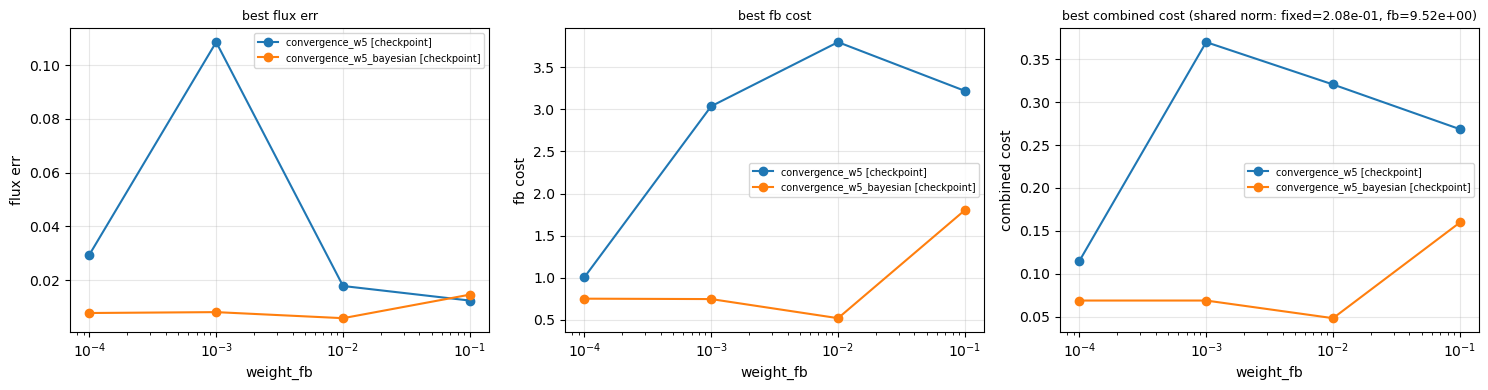

In [20]:
sweeps = df['sweep'].unique()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for sweep in sweeps:
    sub = df[df['sweep'] == sweep].sort_values('weight_fb')
    label = f"{sweep} [{sub['source'].iloc[0]}]"
    axes[0].plot(sub['weight_fb'], sub['best_flux_err'], marker='o', label=label)
    axes[1].plot(sub['weight_fb'], sub['best_fb_cost'], marker='o', label=label)
    axes[2].plot(sub['weight_fb'], sub['best_cost_shared'], marker='o', label=label)

for ax, title, ylabel in zip(
    axes,
    ['best flux err', 'best fb cost', f'best combined cost (shared norm: fixed={shared_norm_fixed:.2e}, fb={shared_norm_fb:.2e})'],
    ['flux err', 'fb cost', 'combined cost']
):
    ax.set_xscale('log')
    ax.set_xlabel('weight_fb')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

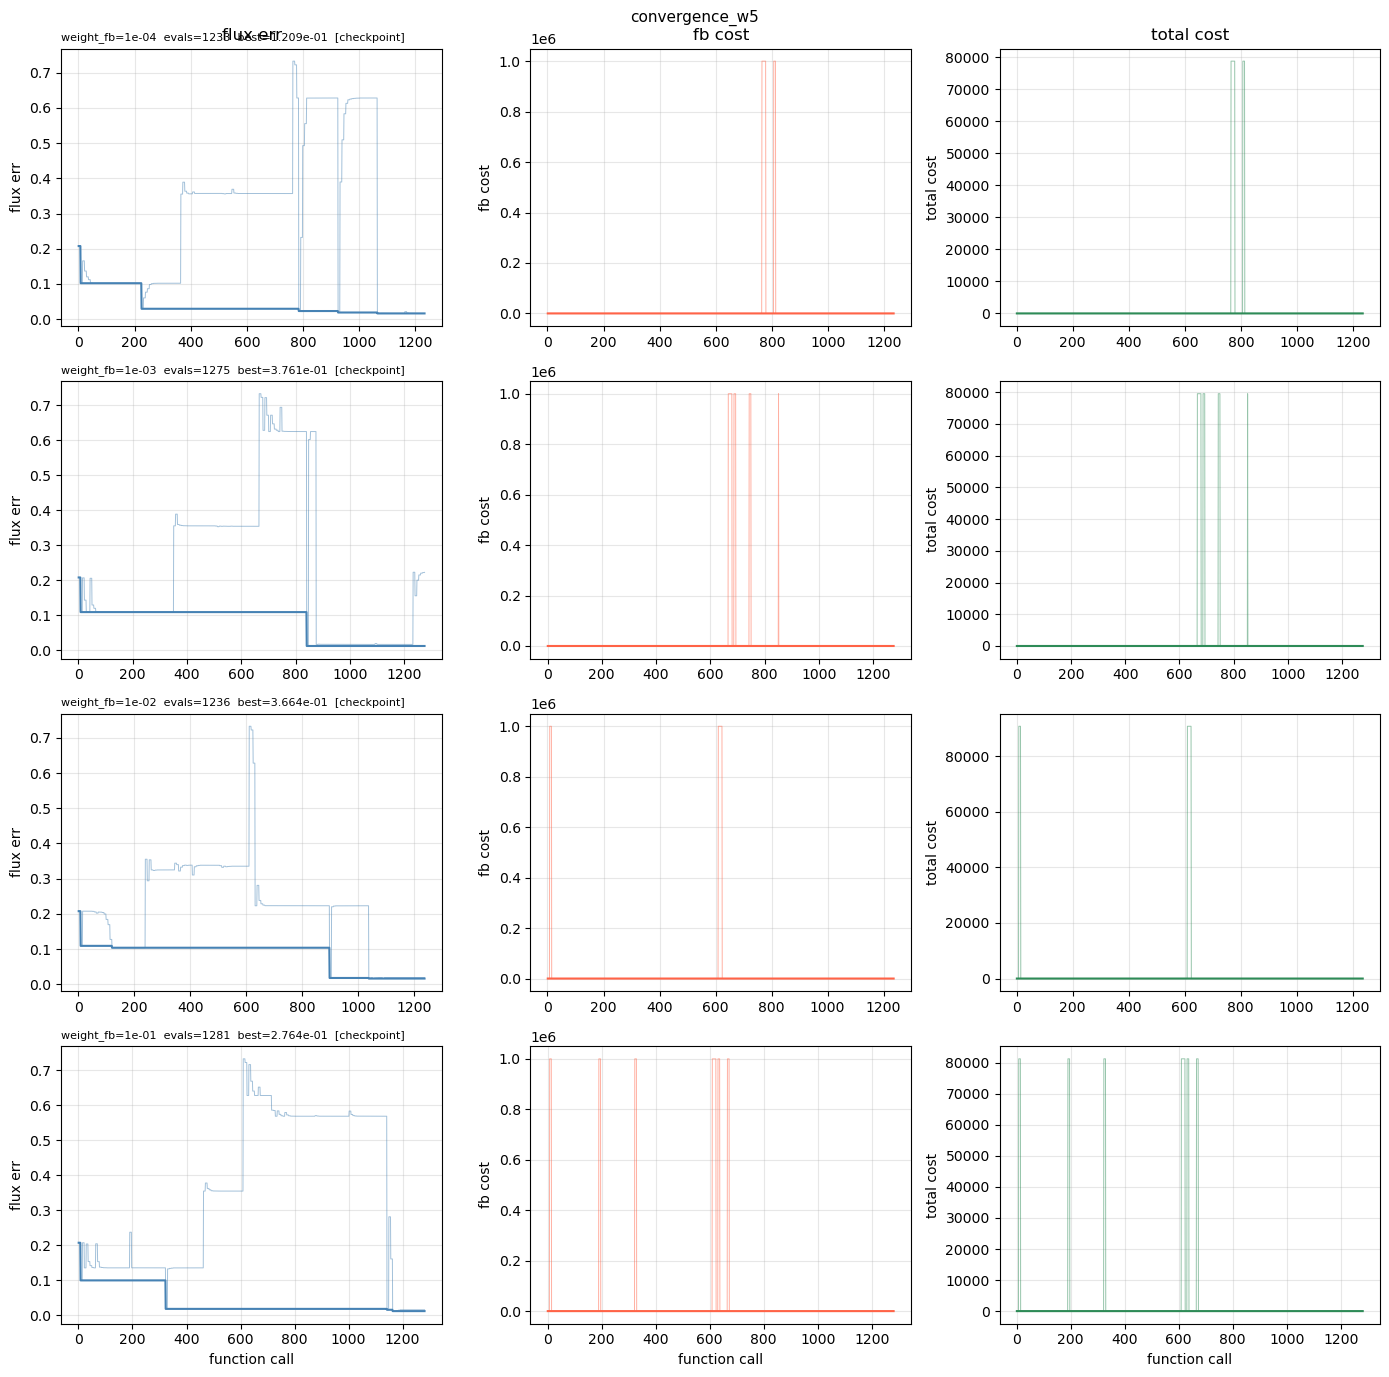

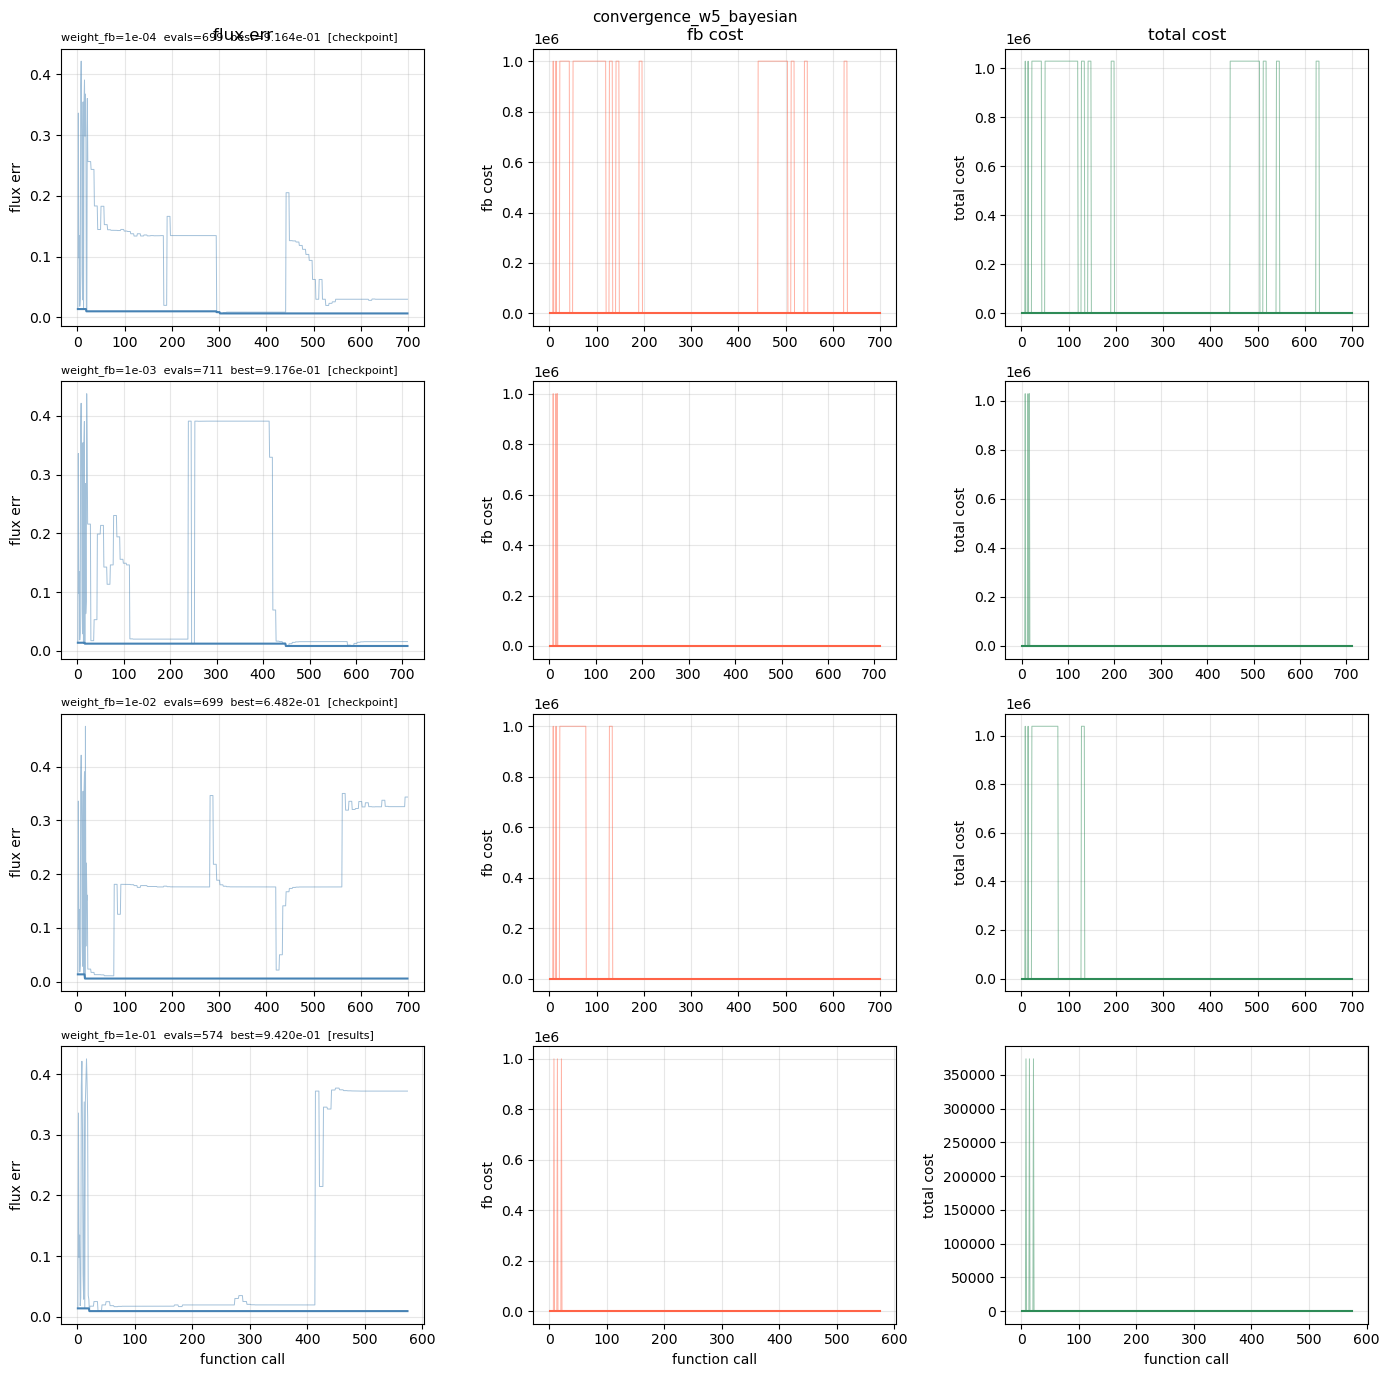

In [21]:
# cost history per run — one figure per sweep
for sweep in sorted(set(r['sweep'] for r in runs)):
    sweep_runs = [r for r in runs if r['sweep'] == sweep]
    n = len(sweep_runs)
    fig, axes = plt.subplots(n, 3, figsize=(14, 3.5 * n), sharex=False, squeeze=False)
    fig.suptitle(sweep, fontsize=11)

    for row, r in enumerate(sorted(sweep_runs, key=lambda x: x['weight_fb'])):
        d = r['data']
        evals = np.arange(1, len(d['cost_history']) + 1)
        total = np.array(d['cost_history'], dtype=float)
        flux = np.array([x if x is not None else np.nan for x in d['flux_err_history']], dtype=float)
        fb = np.array([x if x is not None else np.nan for x in d['fb_cost_history']], dtype=float)

        title = f"weight_fb={r['weight_fb']:.0e}  evals={r['n_evals']}  best={r['best_cost']:.3e}  [{r['source']}]"

        for ax, y, color, label in zip(
            axes[row],
            [flux, fb, total],
            ['steelblue', 'tomato', 'seagreen'],
            ['flux err', 'fb cost', 'total cost']
        ):
            ax.plot(evals, y, lw=0.7, alpha=0.5, color=color)
            running_best = np.minimum.accumulate(np.where(np.isnan(y), np.inf, y))
            running_best[running_best == np.inf] = np.nan
            ax.plot(evals, running_best, lw=1.5, color=color)
            ax.set_ylabel(label)
            ax.grid(True, alpha=0.3)
            if row == 0:
                ax.set_title(label)
            if row == len(sweep_runs) - 1:
                ax.set_xlabel('function call')

        axes[row][0].set_title(title, fontsize=8, loc='left')

    plt.tight_layout()
    plt.show()